<a href="https://colab.research.google.com/github/LuisTT0903/Processamento-de-Sinais1/blob/main/Aula_02/Pratica2Quest%C3%A3o9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

h_banheiro.wav: fs = 22050 Hz, N = 9475 amostras, duracao = 0.430 s

Baixando sinal_taca.wav de https://raw.githubusercontent.com/LuisTT0903/Processamento-de-Sinais1/main/Aula_02/Sinais_Usados/sinal_taca.wav ...
Download concluido.
sinal_taca.wav: fs = 22050 Hz, N = 19100 amostras, duracao = 0.866 s

h_banheiro.wav: pico de maior magnitude no espectro = 5757.4 Hz
sinal_taca.wav: pico de maior magnitude no espectro = 1097.9 Hz


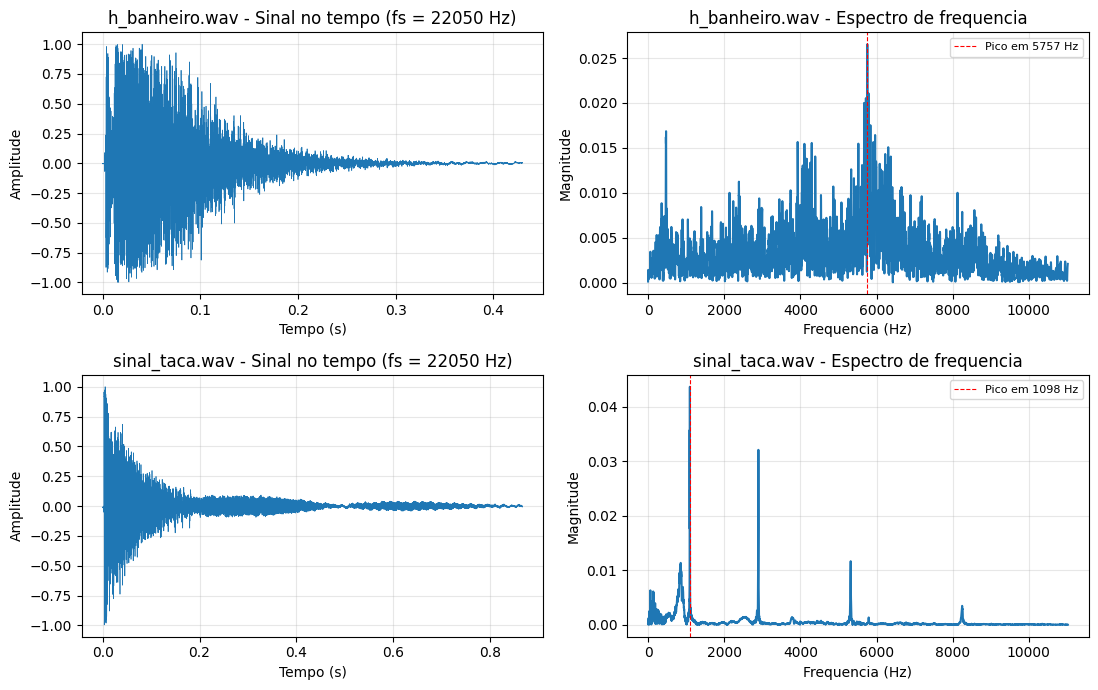


--- h_banheiro.wav ---



--- sinal_taca.wav ---


In [ ]:
"""
Questao 9 - Espectro dos sinais h_banheiro.wav e sinal_taca.wav

Objetivo:
    - Ler os dois arquivos de audio
    - Calcular o espectro de cada um via FFT (funcao calculate_spectrum)
    - Plotar a forma de onda no tempo e o espectro de cada sinal

Observacao sobre os nomes dos arquivos (contexto tipico de Processamento
de Sinais): 'h_banheiro.wav' sugere uma resposta ao impulso (h[n]) medida
em um banheiro (ambiente com bastante reverberacao, por ser um espaco
pequeno e com superficies rigidas/reflexivas - azulejos, por exemplo).
'sinal_taca.wav' sugere a gravacao de uma taca de vidro sendo excitada
(por exemplo, tocada/batida ou fazendo-a "cantar" ao friccionar a borda),
sinal tipicamente dominado por poucas frequencias bem definidas (ressonancias
naturais da taca). Ajuste os nomes dos arquivos abaixo caso sejam diferentes
dos usados no seu repositorio.
"""

import os
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
import IPython.display as ipd


# ---------------------------------------------------------------------------
# Funcao calculate_spectrum (mesma das questoes anteriores)
# ---------------------------------------------------------------------------
def calculate_spectrum(x, fs):
    """
    Calcula o espectro de magnitude de um sinal discreto x[n] amostrado a fs.
    Retorna freqs (Hz, parte positiva 0 a fs/2) e mag (magnitude normalizada).
    """
    N = len(x)
    X = np.fft.fft(x)
    freqs_completo = np.fft.fftfreq(N, d=1/fs)
    metade = N // 2
    freqs = freqs_completo[:metade]
    mag = (2.0 / N) * np.abs(X[:metade])
    return freqs, mag


# ---------------------------------------------------------------------------
# Funcao auxiliar para ler e normalizar um arquivo .wav
# ---------------------------------------------------------------------------
def ler_wav(caminho):
    """
    Le um arquivo .wav e retorna (fs, x), com x normalizado entre -1 e 1
    e reduzido a um unico canal (mono), caso o arquivo seja estereo.
    """
    fs, x = wavfile.read(caminho)
    if x.ndim > 1:
        x = x[:, 0]
    x = x.astype(np.float64)
    x = x / np.max(np.abs(x))
    return fs, x


# ---------------------------------------------------------------------------
# Download/leitura dos arquivos de audio
# ---------------------------------------------------------------------------
# Ajuste a URL base e os nomes dos arquivos conforme a estrutura do seu
# repositorio (mesma pasta usada para o handel.wav nas questoes anteriores).
usar_colab = True
base_url = ("https://raw.githubusercontent.com/LuisTT0903/Processamento-de-Sinais1/"
            "main/Aula_02/Sinais_Usados/")

arquivos = {
    "banheiro": "h_banheiro.wav",
    "taca": "sinal_taca.wav",
}

sinais = {}   # guarda (fs, x) de cada arquivo lido

for nome, arquivo in arquivos.items():
    if usar_colab and not os.path.exists(arquivo):
        url = base_url + arquivo
        print(f"Baixando {arquivo} de {url} ...")
        urllib.request.urlretrieve(url, arquivo)
        print("Download concluido.")

    fs, x = ler_wav(arquivo)
    sinais[nome] = (fs, x)
    print(f"{arquivo}: fs = {fs} Hz, N = {len(x)} amostras, "
          f"duracao = {len(x)/fs:.3f} s\n")


# ---------------------------------------------------------------------------
# (a) Calculo e plot do espectro de cada sinal
# ---------------------------------------------------------------------------
fig, eixos = plt.subplots(len(sinais), 2, figsize=(11, 3.5 * len(sinais)))

for i, (nome, (fs, x)) in enumerate(sinais.items()):

    N = len(x)
    t = np.arange(N) / fs

    freqs, mag = calculate_spectrum(x, fs)

    # Identifica o pico de maior magnitude no espectro
    f_pico = freqs[np.argmax(mag)]
    print(f"{arquivos[nome]}: pico de maior magnitude no espectro = {f_pico:.1f} Hz")

    # --- Sinal no tempo ---
    eixos[i, 0].plot(t, x, linewidth=0.5)
    eixos[i, 0].set_title(f"{arquivos[nome]} - Sinal no tempo (fs = {fs} Hz)")
    eixos[i, 0].set_xlabel("Tempo (s)")
    eixos[i, 0].set_ylabel("Amplitude")
    eixos[i, 0].grid(True, alpha=0.3)

    # --- Espectro de frequencia ---
    eixos[i, 1].plot(freqs, mag)
    eixos[i, 1].set_title(f"{arquivos[nome]} - Espectro de frequencia")
    eixos[i, 1].set_xlabel("Frequencia (Hz)")
    eixos[i, 1].set_ylabel("Magnitude")
    eixos[i, 1].axvline(f_pico, color='r', linestyle='--', linewidth=0.8,
                         label=f"Pico em {f_pico:.0f} Hz")
    eixos[i, 1].legend(loc="upper right", fontsize=8)
    eixos[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("q9_espectros.png", dpi=150)
plt.show()


# ---------------------------------------------------------------------------
# Ouvir os dois sinais (util para embasar o comentario do item b)
# ---------------------------------------------------------------------------
for nome, (fs, x) in sinais.items():
    print(f"\n--- {arquivos[nome]} ---")
    ipd.display(ipd.Audio(x, rate=fs, autoplay=False))

Os dois sinais apresentam características bem diferentes, tanto na forma de onda no tempo quanto no espectro de frequência — cada um consistente com sua origem física provável.

h_banheiro.wav — no domínio do tempo, o sinal mostra uma amplitude alta e caótica logo no início (pico próximo de 1.0), decaindo de forma gradual e irregular ao longo de aproximadamente 0,4 s, sem nunca "sumir" completamente — apenas se atenuando lentamente até quase zero. Esse comportamento é típico de uma resposta ao impulso (RIR — Room Impulse Response): o pico inicial representa o som direto (excitação abrupta, como um estalo/palma), e o decaimento arrastado corresponde à reverberação do ambiente — múltiplas reflexões do som nas paredes, piso e teto se somando e se atenuando com o tempo. Isso é coerente com um banheiro: espaço pequeno, com superfícies rígidas e refletoras (azulejos, vidro, metal), que favorece reverberação forte. No espectro, não há um único pico dominante e sim uma distribuição de energia relativamente espalhada, com destaque para um pico mais evidente perto de 5757 Hz e outras concentrações de energia entre 2000–6000 Hz — um padrão irregular, sem tons puros bem definidos, condizente com a resposta acústica de um ambiente (que não tem uma "nota" única, mas sim ressonâncias em várias frequências relacionadas à geometria do espaço).

sinal_taca.wav — o sinal no tempo tem um comportamento parecido em formato (pico inicial alto seguido de decaimento), mas dura mais tempo (~0,9 s) e o decaimento é bem mais suave e "limpo" na cauda, sugerindo uma oscilação sustentada em vez de um ruído reverberante caótico. Isso é típico do som de uma taça de vidro sendo excitada (por percussão ou fricção na borda) — o vidro vibra em suas frequências naturais de ressonância, que decaem lentamente por atrito/amortecimento, mas mantêm um padrão oscilatório regular. Isso fica evidente no espectro: ao contrário do h_banheiro.wav, aqui existe um pico espectral muito bem definido e dominante em ~1098 Hz — provavelmente a frequência fundamental de ressonância da taça — junto com picos secundários bem mais estreitos em ~2900 Hz e ~5400 Hz, que são consistentes com harmônicos/parciais dessa ressonância fundamental (múltiplos aproximados da frequência base). Esse padrão de poucos picos estreitos e bem isolados é característico de objetos físicos com ressonâncias naturais bem definidas (como taças, sinos, cordas), diferente da distribuição espalhada de um ambiente acústico.

Comparação geral — a diferença mais marcante entre os dois sinais está na forma do espectro: h_banheiro.wav tem energia espalhada e irregular ao longo de uma faixa larga (característico de reverberação ambiental — o espaço "colore" todas as frequências de forma complexa, sem favorecer nenhuma em particular), enquanto sinal_taca.wav tem energia concentrada em poucos picos estreitos e bem definidos (característico de um objeto ressonante com modos de vibração naturais específicos). Essa distinção ilustra bem, na prática, como o espectro de frequência revela a natureza física da fonte sonora: ambientes reverberantes geram espectros "largos e ruidosos", enquanto objetos ressonantes geram espectros "estreitos e tonais".